# Running the OphydAsync Tutorial

## References
1. [Ophyd-Async Tutorials](https://blueskyproject.io/ophyd-async/main/tutorials.html#)

In [1]:
"""Used for tutorial `Using Devices`."""

# Import bluesky and ophyd
from pathlib import PurePath
from tempfile import mkdtemp

import bluesky.plan_stubs as bps  # noqa: F401
import bluesky.plans as bp  # noqa: F401
import bluesky.preprocessors as bpp  # noqa: F401
from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.run_engine import RunEngine, autoawait_in_bluesky_event_loop

from ophyd_async import sim
from ophyd_async.core import StaticPathProvider, UUIDFilenameProvider, init_devices

# Create a run engine and make ipython use it for `await` commands
RE = RunEngine(call_returns_result=True)
autoawait_in_bluesky_event_loop()

# Add a callback for plotting
bec = BestEffortCallback()
RE.subscribe(bec)

# Make a pattern generator that uses the motor positions
# to make a test pattern. This simulates the real life process
# of X-ray scattering off a sample
pattern_generator = sim.PatternGenerator()

# Make a path provider that makes UUID filenames within a static
# temporary directory
path_provider = StaticPathProvider(UUIDFilenameProvider(), PurePath(mkdtemp()))

# All Devices created within this block will be
# connected and named at the end of the with block
with init_devices():
    # Create a sample stage with X and Y motors that report their positions
    # to the pattern generator
    stage = sim.SimStage(pattern_generator)
    # Make a detector device that gives the point value of the pattern generator
    # when triggered
    pdet = sim.SimPointDetector(pattern_generator)
    # Make a detector device that gives a gaussian blob with intensity based
    # on the point value of the pattern generator when triggered
    bdet = sim.SimBlobDetector(path_provider, pattern_generator)

In [2]:
stage.x.name

'stage-x'

In [3]:
stage.x.read()

<coroutine object StandardReadable.read at 0x0000019973E10A00>

In [4]:
await stage.x.read()

{'stage-x': {'value': 0.0,
  'timestamp': 1781815781.6888733,
  'alarm_severity': 0}}

In [5]:
RE(bps.rd(stage.x))

RunEngineResult(run_start_uids=(), plan_result=0.0, exit_status='success', interrupted=False, reason='', exception=None)

In [6]:
RE(bps.mv(stage.x, 1.5))

RunEngineResult(run_start_uids=(), plan_result=(<WatchableAsyncStatus, device: stage-x, task: <coroutine object AsyncStatusBase.__init__.<locals>.wait_with_error_message at 0x000001991887C840>, done>,), exit_status='success', interrupted=False, reason='', exception=None)



Transient Scan ID: 1     Time: 2026-06-18 13:54:23
Persistent Unique Scan ID: '652c4f69-608c-47ef-a0ea-2b4f0b252bfa'
New stream: 'primary'
+-----------+------------+------------+------------+----------------------+----------------------+----------------------+
|   seq_num |       time |    stage-x |    stage-y | pdet-channel-1-value | pdet-channel-2-value | pdet-channel-3-value |
+-----------+------------+------------+------------+----------------------+----------------------+----------------------+
|         1 | 13:54:26.7 |      1.000 |      2.000 |                  921 |                  887 |                  859 |
|         2 | 13:54:28.6 |      1.000 |      2.500 |                  959 |                  926 |                  898 |
|         3 | 13:54:30.4 |      1.000 |      3.000 |                  937 |                  903 |                  875 |
|         4 | 13:54:32.8 |      1.500 |      2.000 |                  976 |                  975 |                  974 |
|    

RunEngineResult(run_start_uids=('652c4f69-608c-47ef-a0ea-2b4f0b252bfa',), plan_result='652c4f69-608c-47ef-a0ea-2b4f0b252bfa', exit_status='success', interrupted=False, reason='', exception=None)

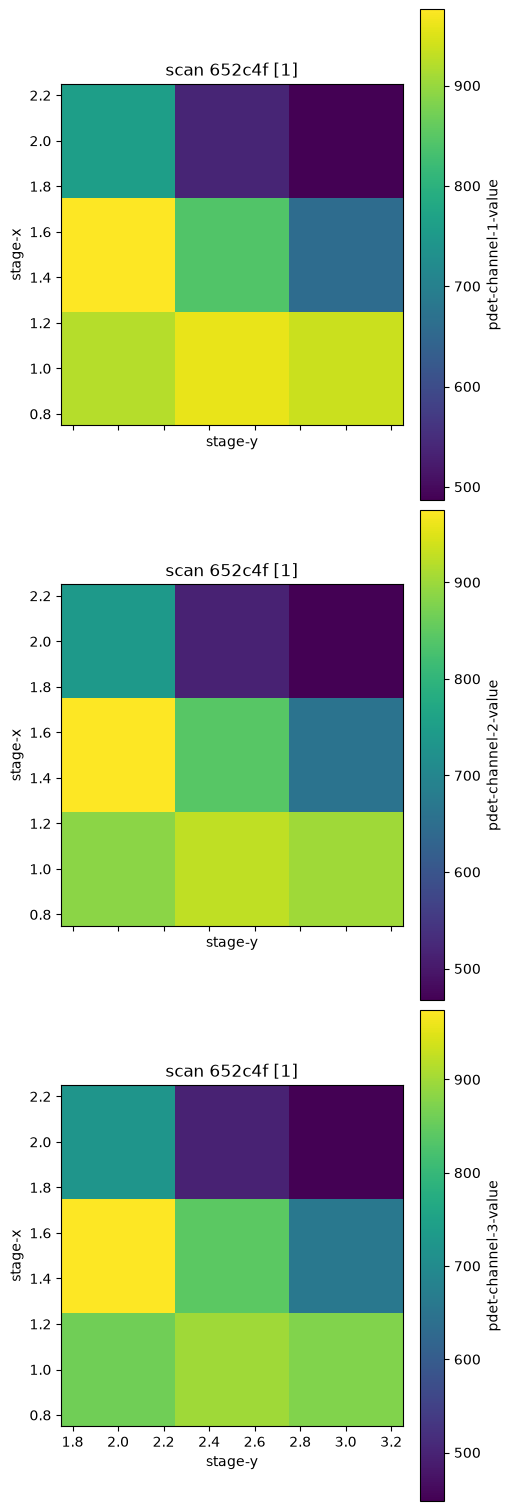

In [7]:
RE(bp.grid_scan([pdet], stage.x, 1, 2, 3, stage.y, 2, 3, 3))